<a href="https://colab.research.google.com/github/AliffiaHumrh/2311531004_AliffiaHumairah_ImageProcessing/blob/main/ImageProcessing_Pertemuan5_2311531004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

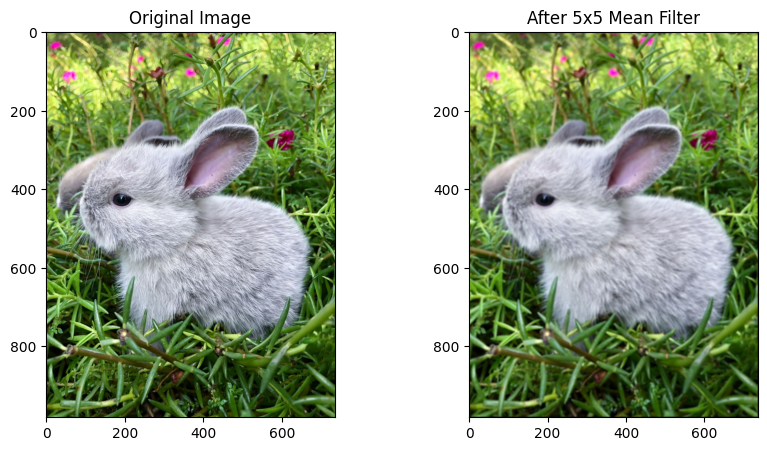

In [22]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def manual_convolution(image_array, kernel):
    # Mendapatkan dimensi citra dan kernel
    img_height, img_width, channels = image_array.shape
    k_height, k_width = kernel.shape

    # Menghitung padding (untuk kernel 5x5, padding adalah 2)
    pad_h = k_height // 2
    pad_w = k_width // 2

    # Membuat canvas kosong untuk output
    output = np.zeros_like(image_array)

    # Menambahkan padding pada citra input (Zero Padding)
    padded_img = np.pad(image_array, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')

    # Proses Konvolusi
    for c in range(channels): # Loop setiap warna R, G, B
        for y in range(img_height):
            for x in range(img_width):
                # Mengambil area sesuai ukuran kernel
                region = padded_img[y:y+k_height, x:x+k_width, c]
                # Operasi konvolusi: jumlah dari (region * kernel)
                # Karena kernel rataan 5x5 nilainya semua 1/25, ini sama dengan rata-rata
                output[y, x, c] = np.sum(region * kernel)

    return output.astype(np.uint8)

# 1. Load Citra
image_path = 'kelincii.jpg' # Ganti dengan nama file gambarmu
img = Image.open(image_path).convert('RGB')
img_array = np.array(img)

# 2. Definisi Kernel Rataan 5x5 (Linear Filter)
# Setiap elemen adalah 1/(5*5) = 1/25
kernel_size = 5
kernel_mean_5x5 = np.ones((kernel_size, kernel_size)) / (kernel_size**2)

# 3. Jalankan Konvolusi
result_array = manual_convolution(img_array, kernel_mean_5x5)

# 4. Tampilkan & Simpan Hasil
result_img = Image.fromarray(result_array)
result_img.save('hasill.jpg')

# Visualisasi sederhana
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_array)
plt.subplot(1, 2, 2)
plt.title("After 5x5 Mean Filter")
plt.imshow(result_array)
plt.show()

# **PENJELASAN KODE**

In [23]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO



*   import numpy as np: Mengelola data dalam bentuk n-dimensional array. Gambar digital sebenarnya hanyalah sekumpulan angka (intensitas warna). Citra grayscale direpresentasikan sebagai matriks 2D, sedangkan citra berwarna (RGB) sebagai matriks 3D. Numpy digunakan untuk melakukan operasi matematika pada piksel-piksel tersebut (seperti konvolusi yang kita bahas tadi).
*   from PIL import Image: Membuka, memanipulasi, dan menyimpan berbagai format file gambar (JPEG, PNG, dsb). Digunakan untuk membaca file gambar dan mengubahnya ke format yang bisa dipahami oleh Python sebelum dikonversi menjadi array Numpy.
*   import matplotlib.pyplot as plt: Menampilkan gambar, membuat plot, histogram warna, atau grafik. Fungsi plt.imshow() nanti akan sering kamu gunakan untuk melihat hasil olahan gambarmu di layar.
*   import requests: Digunakan untuk melakukan HTTP request guna mengambil data gambar dari sebuah URL.
*   from io import BytesIO: Digunakan untuk mengubah data biner yang diunduh oleh requests agar bisa dibaca oleh Pillow seolah-olah data tersebut adalah file gambar fisik di komputer kamu.



In [24]:
def manual_convolution(image_array, kernel):
    # Mendapatkan dimensi citra (Tinggi, Lebar, Kanal Warna)
    img_height, img_width, channels = image_array.shape
    k_height, k_width = kernel.shape

    # Menghitung padding agar ukuran output tetap sama (5x5 -> padding 2)
    pad_h = k_height // 2
    pad_w = k_width // 2

    # Membuat canvas kosong (hitam) seukuran gambar asli
    output = np.zeros_like(image_array)

    # Menambahkan Zero Padding di sekeliling gambar
    padded_img = np.pad(image_array, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')

    # Proses Iterasi (Sliding Window)
    for c in range(channels): # Untuk R, G, dan B
        for y in range(img_height):
            for x in range(img_width):
                # Ambil area 5x5
                region = padded_img[y:y+k_height, x:x+k_width, c]
                # Kalikan dengan kernel dan jumlahkan (Mean Filter)
                output[y, x, c] = np.sum(region * kernel)

    return output.astype(np.uint8)



*   **img_height, img_width, channels = image_array.shape
k_height, k_width = kernel.shape**: Mengambil ukuran gambar (Tinggi, Lebar, dan jumlah warna seperti RGB) serta ukuran filter (kernel) yang akan digunakan. Kernel biasanya berukuran ganjil (3x3, 5x5) agar memiliki titik pusat yang jelas.

*   **pad_h = k_height // 2
pad_w = k_width // 2**: Secara alami, operasi konvolusi akan membuat gambar hasil menjadi lebih kecil karena bagian pinggir gambar tidak punya cukup "tetangga" untuk dikalikan dengan kernel. Jika kernel $5 \times 5$, maka butuh tambahan 2 piksel di setiap sisi agar pusat kernel bisa menyentuh piksel paling pinggir dari gambar asli.

*   **output = np.zeros_like(image_array)
padded_img = np.pad(image_array, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')**: Membuat matriks hitam kosong yang ukurannya sama persis dengan gambar asli sebagai tempat menampung hasil. Dan menambahkan "bingkai" berisi angka 0 (hitam) di sekeliling gambar. Ini memastikan ukuran output tetap sama dengan input (Same Padding).

*   **for c in range(channels)**: Melakukan konvolusi pada setiap layer warna (Merah, Hijau, Biru) secara terpisah.

*   **for y dan for x**: Menggeser jendela kernel dari pojok kiri atas ke kanan bawah gambar.

*   **region = padded_img[y:y+k_height, x:x+k_width, c]
output[y, x, c] = np.sum(region * kernel)**: region: Mengambil potongan gambar (misal ukuran 5x5) yang sedang ditutupi oleh kernel. region * kernel: Melakukan perkalian elemen-per-elemen (Element-wise multiplication). np.sum: Menjumlahkan seluruh hasil perkalian tersebut menjadi satu angka tunggal yang akan menjadi nilai piksel baru di koordinat $(y, x)$.

*   **return output.astype(np.uint8)**: Matriks hasil perhitungan biasanya bertipe float (desimal). Karena standar gambar digital menggunakan rentang 0-255, kita harus mengubahnya kembali ke tipe uint8 (Unsigned Integer 8-bit).



In [25]:
# 1. Upload/Load Gambar
image_path = 'kelincii.jpg'
img = Image.open(image_path).convert('RGB')
img_array = np.array(img)

# 2. Definisi Kernel Rataan 5x5 sesuai Modul
kernel_size = 5
kernel_mean_5x5 = np.ones((kernel_size, kernel_size)) / 25.0



*   convert('RGB'): Ini langkah krusial. Kadang gambar memiliki format RGBA (dengan transparansi) atau Grayscale. Dengan memaksa ke RGB, kita memastikan matriks memiliki 3 kanal warna (Red, Green, Blue).
*   np.array(img): Mengubah objek gambar menjadi matriks angka (Numpy Array). Jika gambar berukuran $400 \times 400$ piksel, maka img_array akan memiliki struktur $(400, 400, 3)$.
*   np.ones((5, 5)): Membuat matriks berisi angka 1 sebanyak 25 buah.
*   / 25.0: Ini adalah proses normalisasi.

Dibagi 25 karna dalam Mean Filter, kita ingin mengambil rata-rata. Jika kita tidak membaginya dengan jumlah elemen (5x5 = 25), nilai piksel hasil konvolusi akan menjadi sangat besar (over-exposure) dan gambar akan berubah menjadi putih polos. Dengan membaginya, total nilai dalam satu kernel adalah tepat 1. Ini menjaga tingkat kecerahan (brightness) gambar tetap sama dengan aslinya.



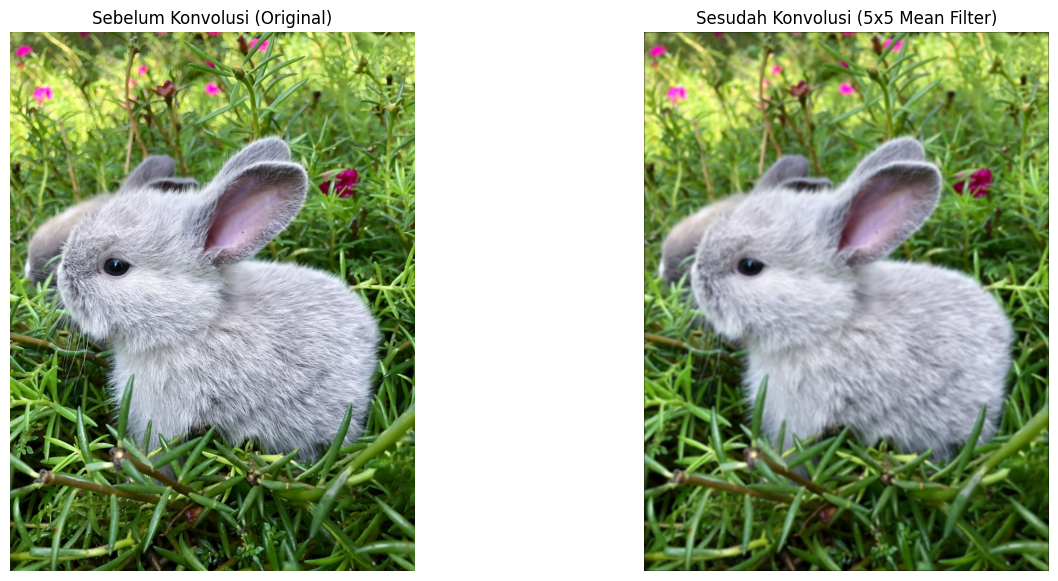

In [26]:
# Jalankan konvolusi
result_array = manual_convolution(img_array, kernel_mean_5x5)

# Tampilkan Hasil
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.title("Sebelum Konvolusi (Original)")
plt.imshow(img_array)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sesudah Konvolusi (5x5 Mean Filter)")
plt.imshow(result_array)
plt.axis('off')

plt.show()

# Simpan hasil untuk dikumpulkan ke GitHub
result_img = Image.fromarray(result_array)
result_img.save('hasil.jpg')



*   result_array = manual_convolution(img_array, kernel_mean_5x5): Baris ini memanggil fungsi manual_convolution yang sudah kamu definisikan di awal.
*   figsize=(15, 7): Mengatur ukuran jendela tampilan agar cukup lebar untuk membandingkan dua gambar berdampingan.
*   plt.subplot(1, 2, X): Membagi area tampilan menjadi 1 baris dan 2 kolom. Angka terakhir (1 atau 2) menentukan posisi gambar tersebut.
*   plt.axis('off'): Menghilangkan angka koordinat (sumbu X dan Y) di pinggir gambar agar tampilan lebih bersih seperti galeri foto.
*   Image.fromarray: Ini adalah kebalikan dari np.array. Karena result_array masih berupa susunan angka (Numpy), kita harus mengubahnya kembali menjadi objek "Gambar" (PIL Image) agar bisa dikenali oleh sistem operasi sebagai file gambar.
*   result_img.save: Menyimpan hasil olahan ke dalam memori penyimpanan (disk) dengan nama hasil.jpg. Jika kamu menggunakan Google Colab, file ini akan muncul di folder samping untuk diunduh.



# **Kesimpulan**

Hasil akhir dari kode ini akan menunjukkan gambar yang lebih halus atau sedikit kabur. Hal ini membuktikan bahwa Konvolusi berhasil memodifikasi nilai piksel berdasarkan tetangganya. Kernel Mean Filter efektif untuk menghilangkan detail tajam (noise) dengan cara merata-ratakan warna di area $5 \times 5$.